# RF regression on sequence  4 features
Minimal, readable pipeline split into cells.

In [18]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18



# 1) Imports & config The in R studion done 4 feature were computed an used for the training.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from scipy.interpolate import PchipInterpolator
    _HAVE_PCHIP = True
except Exception:
    _HAVE_PCHIP = False

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("central", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

RF_PARAMS = dict(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
)


Define the area window

In [3]:
# ---- shape feature builder: returns X (DataFrame) ----
import re
import numpy as np
import pandas as pd

FAMILIES    = ["HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
   ]   # edit if needed
KEEP_WINDOW = (5, 23)                   # inclusive positions
EXCLUDE_IF_CONTAINS = ("rep",)          # optional substring filter

def build_X_feature(df: pd.DataFrame,
            families=FAMILIES,
            keep_window=KEEP_WINDOW,
            exclude_contains=EXCLUDE_IF_CONTAINS) -> pd.DataFrame:
    """Select MGW/ProT/Roll columns with trailing _pos index in [6..24] and return numeric DataFrame."""
    start_idx, end_idx = keep_window
    cols = []
    for c in df.columns:
        base = c.split("_")[0] if "_" in c else None
        if base not in families:
            continue
        m = re.search(r"_(\d+)$", c)
        if not m:
            continue
        pos = int(m.group(1))
        if not (start_idx <= pos <= end_idx):
            continue
        if exclude_contains and any(s in c for s in exclude_contains):
            continue
        cols.append(c)
    # numeric df (no imputation/variance here)
    return df[cols].apply(pd.to_numeric, errors="coerce")



## 4) Train, calibrate, evaluate

In [4]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Load & filter
df = pd.read_csv(INFILE)
#df = pd.read_csv("merged_output_balanced.csv")
df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X_feature(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)


# 5) Train-only variance filter + imputer (prevents leakage)
var_mask = Xtr.var(ddof=0) > 1e-12
Xtr = Xtr.loc[:, var_mask]
Xte = Xte.loc[:, var_mask.index[var_mask]]

imp = SimpleImputer(strategy="mean")
Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte = pd.DataFrame(imp.transform(Xte),   columns=Xte.columns, index=Xte.index)



rf_unw = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr)
rf_w   = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr, sample_weight=wtr)

print("Train R² unweighted:", r2_score(ytr, rf_unw.predict(Xtr)))
print("Train R² weighted:",   r2_score(ytr, rf_w.predict(Xtr)))

rf = rf_w # <<< added: choose the model you want to use below (or rf_unw)

#




Train R² unweighted: 0.934851379456086
Train R² weighted: 0.9375447325236665


## 5) Plots & saving predictions

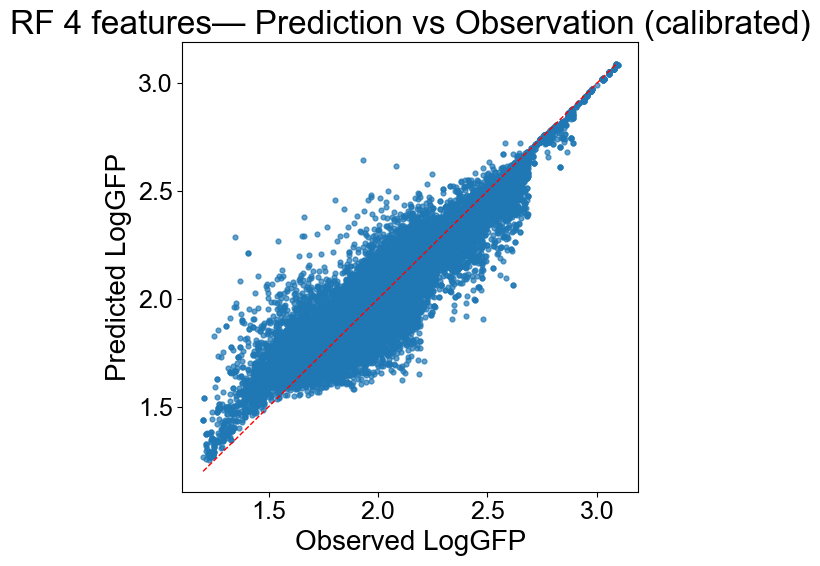

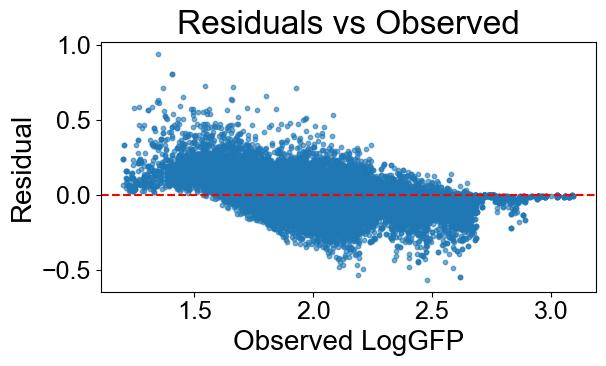

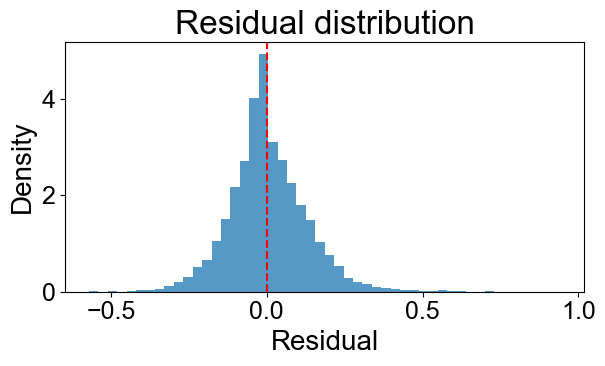

Saved: seq_rf_preds.csv
Mean residual: 0.003336994686303961


In [5]:
# ---- Compute predictions cleanly ----
y_pred = rf.predict(Xte)          # <--- use your model here (rf / hgb / etc.)
y_pred = np.array(y_pred).ravel() # ensure 1D

# If you had a raw model output (e.g., before calibration) define it here
# Otherwise, just set it equal:
y_pred_raw = y_pred.copy()

# ---- Helper to save plots ----
def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{OUT}_{name}.png", dpi=300)
    plt.show()
    plt.close(fig)

# ---- 1. Predicted vs Observed ----
fig = plt.figure(figsize=(6,6))
plt.scatter(yte, y_pred, s=12, alpha=0.7)

lo = float(min(yte.min(), y_pred.min()))
hi = float(max(yte.max(), y_pred.max()))
plt.plot([lo,hi], [lo,hi], 'r--', lw=1)

plt.xlabel("Observed LogGFP")
plt.ylabel("Predicted LogGFP")
plt.title("RF 4 features— Prediction vs Observation (calibrated)")

show_and_save(fig, "pred_vs_obs")

# ---- 2. Residuals ----
res = y_pred - yte

fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte, res, s=10, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP")
plt.ylabel("Residual")
plt.title("Residuals vs Observed")

show_and_save(fig, "residuals_vs_obs")

# ---- 3. Residual distribution ----
fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--')
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Residual distribution")

show_and_save(fig, "residual_hist")

# ---- 4. Export CSV ----
pd.DataFrame({
    "y_true": yte,
    "y_pred_raw": y_pred_raw,
    "y_pred": y_pred
}).to_csv(f"{OUT}_preds.csv", index=False)

print("Saved:", f"{OUT}_preds.csv")
bias = res.mean()
print("Mean residual:", bias)

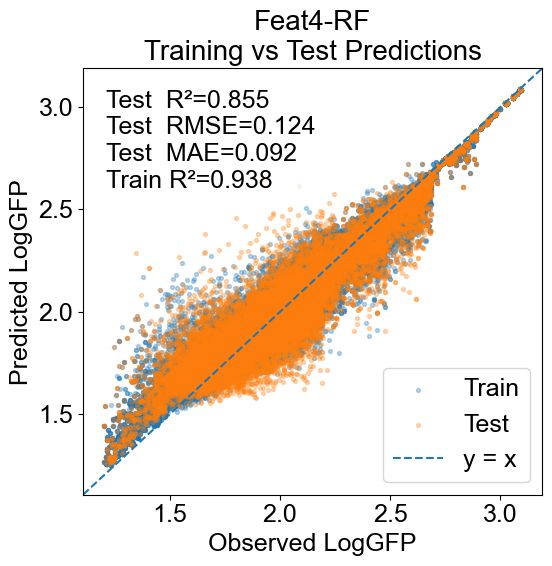

Saved figure -> rf_train_vs_test.png


In [22]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF — Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te_feature)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("RF 4 feature— Training vs Test Predictions.png", dpi=600)
    plt.savefig(
    "Feat4-RF— Training vs Test Predictions.pdf",
    bbox_inches="tight"
)
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="Feat4-RF\n"
                        "Training vs Test Predictions")

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


o the  AUPRC prediction to see how well it predicts strong ans  low expression 

In [7]:
# --- Prepare save ---
try:
    yhat_te_feature
except NameError:
    # if calibrated predictions exist:
    if 'calib' in locals():
        s_te = rf.predict(Xte)
        yhat_te = apply_calibrator(s_te, calib)
    else:
        # otherwise just use raw predictions
        yhat_te_feature = rf.predict(Xte)


In [8]:
pd.DataFrame({"yte": yte, "yhat_te_feature": yhat_te_feature}).to_csv("feature_model_results.csv", index=False)

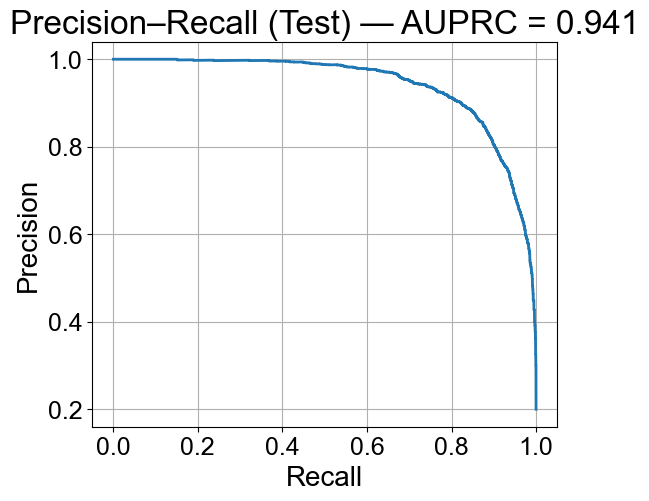

In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# --- setup ---
y_true_cont = yte
y_score = yhat_te_feature  # predicted continuous values

# --- define positives as top X% ---
POS_FRAC = 0.20  # top 20%
threshold = np.percentile(y_true_cont, 100 * (1 - POS_FRAC))
y_true_bin = (y_true_cont >= threshold).astype(int)

# --- compute PR curve ---
precision, recall, _ = precision_recall_curve(y_true_bin, y_score)
auprc = average_precision_score(y_true_bin, y_score)

# --- plot ---
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall (Test) — AUPRC = {auprc:.3f}")
plt.grid(True)
plt.show()


In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- choose scores: calibrated if available, else raw ---
if 'yhat_te_feature' in locals():
    y_score = np.asarray(yhat_te_feature, float)
else:
    y_score = np.asarray(rf.predict(Xte), float)

y_true_cont = np.asarray(yte, float)

print("Shapes:", y_true_cont.shape, y_score.shape)
print("nan?   ", np.isnan(y_true_cont).any(), np.isnan(y_score).any())
print("corr(y_true, y_score) =", np.corrcoef(y_true_cont, y_score)[0,1])

# guard against accidental equality (would produce a too-perfect PR curve)
print("allclose(y_score, y_true_cont)?", np.allclose(y_score, y_true_cont))

# try several positive fractions
for frac in (0.50, 0.30, 0.20, 0.10, 0.05):
    cut = np.quantile(y_true_cont, 1 - frac)
    y_true_bin = (y_true_cont >= cut).astype(int)
    ap = average_precision_score(y_true_bin, y_score)
    print(f"Top {int(frac*100):2d}%  ->  baseline={frac:.3f}  AUPRC={ap:.3f}  positives={y_true_bin.sum()}")


Shapes: (19469,) (19469,)
nan?    False False
corr(y_true, y_score) = 0.9256409338066076
allclose(y_score, y_true_cont)? False
Top 50%  ->  baseline=0.500  AUPRC=0.946  positives=9735
Top 30%  ->  baseline=0.300  AUPRC=0.947  positives=5874
Top 20%  ->  baseline=0.200  AUPRC=0.941  positives=3894
Top 10%  ->  baseline=0.100  AUPRC=0.939  positives=1947
Top  5%  ->  baseline=0.050  AUPRC=0.928  positives=974


Across all tested thresholds (top 5%, 10%, 20% of sequences), the model’s AUPRC is consistently >0.93, while random guessing (the “baseline”) would only yield 0.05–0.5.
→ Your model very effectively identifies high-LogGFP (“strong promoter”) sequences.
The fact that AUPRC barely changes between top-5% and top-50% means your ranking is very robust — it orders sequences almost perfectly from weak → strong.
Together with your regression scores (R²=0.86, MAE=0.088), this means:
The model captures the quantitative trend (R²).
And also ranks the relative strength (AUPRC) correctly.

Blue points (Train): predictions the training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

see the distribution

77874 19469 4.0
Middle counts 1.90–2.00: train= 9649 test= 2435


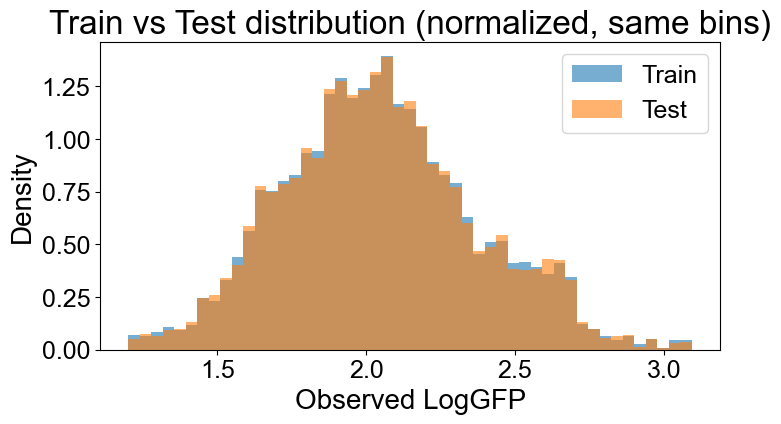

Train quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.951
0.5    2.031
0.6    2.105
0.7    2.197
0.8    2.314
0.9    2.506
1.0    3.094
dtype: float64

Test quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.950
0.5    2.031
0.6    2.106
0.7    2.197
0.8    2.313
0.9    2.505
1.0    3.094
dtype: float64


In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Confirm sizes (should be ~80/20)
print(len(ytr), len(yte), round(len(ytr)/len(yte), 3))

# 2) Count samples in the “middle” band, e.g. 1.90–2.00
mid_mask_tr = (ytr >= 1.90) & (ytr <= 2.00)
mid_mask_te = (yte >= 1.90) & (yte <= 2.00)
print("Middle counts 1.90–2.00:",
      "train=", mid_mask_tr.sum(),
      "test=",  mid_mask_te.sum())

# 3) Compare shapes with SAME bins and density (so areas match)
bins = np.linspace(y.min(), y.max(), 50)
plt.figure(figsize=(8,4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP"); plt.ylabel("Density")
plt.title("Train vs Test distribution (normalized, same bins)")
plt.legend(); plt.show()

# 4) Quantile table to see coverage across the range
qs = np.linspace(0,1,11)
print("Train quantiles:\n", pd.Series(ytr).quantile(qs).round(3))
print("\nTest quantiles:\n",  pd.Series(yte).quantile(qs).round(3))


the saved model

In [12]:
import joblib, json, time

bundle = {
    "version": "shape_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "families": FAMILIES,
    "keep_window": KEEP_WINDOW,
    "exclude": EXCLUDE_IF_CONTAINS,
    "rf_params": getattr(rf, "get_params", lambda: {})(),
    "seed": SEED,
    "feature_columns": list(Xtr.columns),
    "imputer": imp,
    "calibrator": None,
    "model": rf,
}
bundle["y_true_te"] = yte
bundle["y_pred_te"] = yhat_te_feature  
joblib.dump(bundle, "shape_rf_model_4.joblib")
print("Saved: shape_rf_model_4.joblib")


Saved: shape_rf_model_4.joblib


the prediction on new sequnces not seen by the model

In [13]:
# ===== Config =====
MODEL_PATH = "shape_rf_model_4.joblib"        # <- your trained model file
NEW_FILE   = "All_Fasta_sequnes_constructed_features.csv"              # <- your input file (infile)
OUT_FILE   = "pareto_sequences.csv"  # <- your output file (outfile)


# ===== Load bundle =====
B   = joblib.load(MODEL_PATH)
rf  = B["model"]
imp = B.get("imputer", None)

# --- Always use the trained features (ignore var_mask) ---
feat_cols = list(B["feature_columns"])   # these should be your 13 trained features
keep_cols = feat_cols                    # explicitly force this

print("Expecting", len(keep_cols), "trained features:")
print(keep_cols)

# ===== Load new feature table =====
new_raw = pd.read_csv(NEW_FILE, sep=None, engine="python")

# Optional renaming for shape columns
SHAPES = ("HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
  )

pat = re.compile(rf"^({'|'.join(map(re.escape, SHAPES))})[._]?(\d+)$")

def std_name(c):
    m = pat.match(str(c))
    if m:
        shape = m.group(1)
        idx   = int(m.group(2))   # <-- THIS removes leading zeros (01 -> 1)
        return f"{shape}_{idx}"   # gives MGW_6, ProT_7, Roll_10, ...
    return c

new = new_raw.rename(columns={c: std_name(c) for c in new_raw.columns})

# ===== Safety check =====
missing = [c for c in keep_cols if c not in new.columns]
extra   = [c for c in new.columns if c not in keep_cols]

print("Missing:", missing[:10], "…", len(missing))
print("Extra:", extra[:10], "…", len(extra))

if missing:
    raise ValueError("❌ Missing required features: " + ", ".join(missing))

# Align to the exact training feature order
Xnew = new.reindex(columns=keep_cols).apply(pd.to_numeric, errors="coerce")

# Double-check for NaNs
if np.isnan(Xnew.to_numpy()).any():
    raise ValueError("⚠️ NaN values found after alignment — check feature file!")

print("✅ All features aligned and ready for prediction.")

# ===== Predict =====
if imp is not None:
    Xnew = pd.DataFrame(imp.transform(Xnew), columns=keep_cols, index=new.index)

y_pred = rf.predict(Xnew).astype(float)
# ===== Save output (carry through sequence / ids if present) =====
out = pd.DataFrame({"prediction": y_pred}, index=new.index)

# pass through any identifying columns if they exist
passthrough_cols = [c for c in ["sequence_id", "seq_id", "sequence"] if c in new.columns]
for c in reversed(passthrough_cols):
    out.insert(0, c, new[c].values)

# optional: add a core19 column if we have sequences
if "sequence" in out.columns:
    # if your flanks are 4 nt each, keep this exact slice:
    out["core19"] = out["sequence"].astype(str).str.slice(4, -4)
    # fallback for very short strings:
    out.loc[out["core19"].isna() | (out["core19"] == ""), "core19"] = (
        out.loc[out["core19"].isna() | (out["core19"] == ""), "sequence"]
        .astype(str)
        .str.slice(0, 19)
    )
else:
    print("Note: no 'sequence' column in input -> not writing 'core19'.")

out.to_csv(OUT_FILE, sep="\t", index=False)
print(f"Saved: {OUT_FILE}  rows={len(out)}")


Expecting 76 trained features:
['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'ProT_5', 'ProT_6', 'ProT_7', 'ProT_8', 'ProT_9', 'ProT_10', 'ProT_11', 'ProT_12', 'ProT_13', 'ProT_14', 'ProT_15', 'ProT_16', 'ProT_17', 'ProT_18', 'ProT_19', 'ProT_20', 'ProT_21', 'ProT_22', 'ProT_23', 'Roll_5', 'Roll_6', 'Roll_7', 'Roll_8', 'Roll_9', 'Roll_10', 'Roll_11', 'Roll_12', 'Roll_13', 'Roll_14', 'Roll_15', 'Roll_16', 'Roll_17', 'Roll_18', 'Roll_19', 'Roll_20', 'Roll_21', 'Roll_22', 'Roll_23', 'HelT_5', 'HelT_6', 'HelT_7', 'HelT_8', 'HelT_9', 'HelT_10', 'HelT_11', 'HelT_12', 'HelT_13', 'HelT_14', 'HelT_15', 'HelT_16', 'HelT_17', 'HelT_18', 'HelT_19', 'HelT_20', 'HelT_21', 'HelT_22', 'HelT_23']
Missing: [] … 0
Extra: ['sequence_id', 'sequence', 'MGW_1', 'MGW_2', 'MGW_3', 'MGW_4', 'MGW_24', 'MGW_25', 'MGW_26', 'MGW_27'] … 271
✅ All features aligned and ready for p

In [14]:
# 3) Get top 3 strongest predictions overall
top3 = out.sort_values("prediction", ascending=False).head(3)
top3["core19"] = top3["sequence"].str.slice(4, -4)  # trim flanks
top3.to_csv("predictions_top3_4_RF.tsv", sep="\t", index=False)

# 4) Get bottom 3 weakest predictions overall
bottom3 = out.sort_values("prediction", ascending=True).head(3)
bottom3["core19"] = bottom3["sequence"].str.slice(4, -4)  # trim flanks
bottom3.to_csv("predictions_bottom3_4_RF.tsv", sep="\t", index=False)

print("Also wrote:")

print(" - predictions_top3_4_RF.tsv            (strongest 3 overall)")
print(" - predictions_bottom3_4_RF.tsv         (weakest 3 overall)")


Also wrote:
 - predictions_top3_4_RF.tsv            (strongest 3 overall)
 - predictions_bottom3_4_RF.tsv         (weakest 3 overall)


Beeswarm

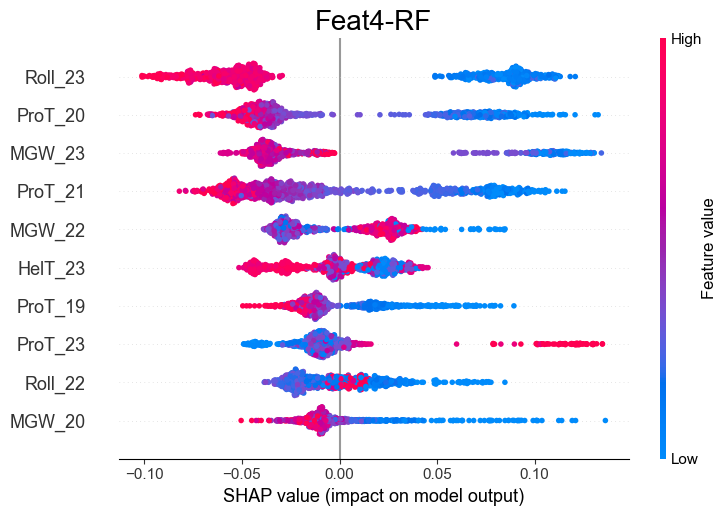

In [21]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# --- Align features to the model ---
if not isinstance(Xte, pd.DataFrame):
    Xte_df = pd.DataFrame(Xte, columns=rf.feature_names_in_)
else:
    Xte_df = Xte.copy()

Xte_df = Xte_df[rf.feature_names_in_]

# --- Subsample ---
n_sample = min(len(Xte_df), 1000)
Xte_df = Xte_df.sample(n_sample, random_state=42)

def make_shap_beeswarm_fast(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5, 3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="center")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)  # create folder if needed
        plt.tight_layout()
        plt.gcf().savefig(savepath,  bbox_inches="tight")

    plt.show()
    plt.close()  # prevents saving the wrong figure later

# --- Run + save ---
make_shap_beeswarm_fast(
    rf,
    Xte_df,
    title="Feat4-RF"
                        ,
    top_k=10,
    savepath="Importance_Picture/Feat4-RF.pdf"
)


Imput the low mid and high example sequnce to se how the model has leand

In [30]:
import joblib

shape_bundle = joblib.load("shape_rf_model_4.joblib")

shape_model = shape_bundle["model"]
feature_names = shape_bundle["feature_columns"]
imputer = shape_bundle["imputer"]   # 👈 THIS LINE WAS MISSING

Example sequences:
['GAAATATCGAGCAGTCAACGTATGGCT', 'GAAAAAATCCCCGGGGAGTCAATGGCT', 'GAAACTTGATACAACAAGGGTTTGGCT', 'GAAACCCAAACATCCAAGGAATTGGCT', 'GAAACATTATATAGACCCCACTCGGCT', 'GAAAATAACTTGCGGCTACCTATGGCT', 'GAAAACACCGTAACCTGTTGATCGGCT', 'GAAAACAGACCTAAGTTGTTGATGGCT', 'GAAACCTAACAAACAGATAGTTAGGCT', 'GAAAACAGACCTAAGTTGTTGATGGCT']
Exact match: 8
Contains: 8
Full sequence matches: 8
Shape model prediction (LogGFP) for candidate: 2.756318082356649


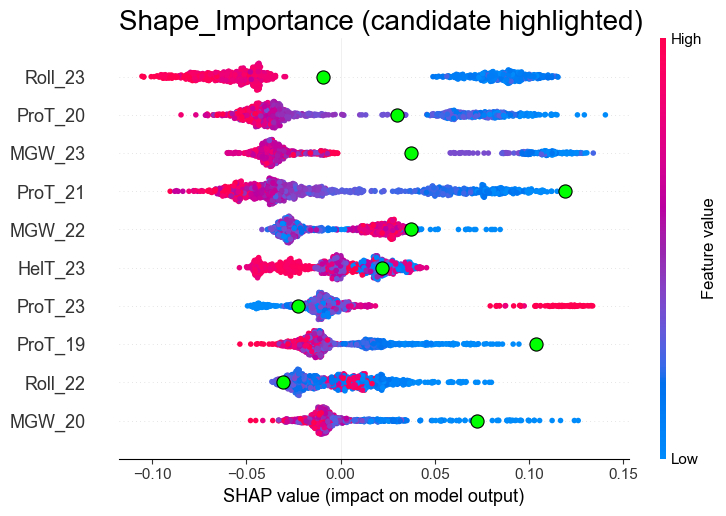

In [78]:
import re
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import joblib

# ================== USER INPUT ==================
full_seq = "GAAATACCCAATACGCATTATAGGGCT".upper()
# =================================================

# ---- Load model bundle first ----
shape_bundle = joblib.load("shape_rf_model_4.joblib")

shape_model = shape_bundle["model"]
feature_names = shape_bundle["feature_columns"]
imputer = shape_bundle["imputer"]

FAMILIES = ["HelT", "MGW", "ProT", "Roll"]
KEEP_WINDOW = tuple(shape_bundle["keep_window"])
EXCLUDE_IF_CONTAINS = tuple(shape_bundle["exclude"])

# ---- Load CSV ----
df_shape = pd.read_csv("merged_output_13infile.csv")
df_shape.columns = df_shape.columns.str.strip()

SEQ_COL = "sequence"
df_shape = pd.read_csv("merged_output_13infile.csv")
df_shape.columns = df_shape.columns.str.strip()

df_shape["sequence_clean"] = (
    df_shape["sequence"]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Example sequences:")
print(df_shape["sequence_clean"].head(10).tolist())

full_seq = "GAAATACCCAATACGCATTATAGGGCT".upper()

print("Exact match:", (df_shape["sequence_clean"] == full_seq).sum())
print("Contains:", df_shape["sequence_clean"].str.contains(full_seq, regex=False).sum())
# ---- Build DNA-shape feature matrix ----
def build_X_feature(
    df: pd.DataFrame,
    families=FAMILIES,
    keep_window=KEEP_WINDOW,
    exclude_contains=EXCLUDE_IF_CONTAINS
) -> pd.DataFrame:

    start_idx, end_idx = keep_window
    cols = []

    for c in df.columns:
        base = c.split("_")[0] if "_" in c else None

        if base not in families:
            continue

        m = re.search(r"_(\d+)$", c)
        if not m:
            continue

        pos = int(m.group(1))

        if not (start_idx <= pos <= end_idx):
            continue

        if exclude_contains and any(s in c for s in exclude_contains):
            continue

        cols.append(c)

    return df[cols].apply(pd.to_numeric, errors="coerce")


# ---- Prepare feature matrix ----
X_feat_raw = build_X_feature(df_shape)
X_feat_raw = X_feat_raw[feature_names]

X_feat_all = pd.DataFrame(
    imputer.transform(X_feat_raw),
    columns=feature_names,
    index=df_shape.index
)

# ---- Find candidate by FULL sequence ----
df_shape["sequence_clean"] = (
    df_shape[SEQ_COL]
    .astype(str)
    .str.upper()
    .str.strip()
)

cand_idx = df_shape.index[df_shape["sequence_clean"] == full_seq]

print("Full sequence matches:", len(cand_idx))

if len(cand_idx) == 0:
    raise ValueError("Full sequence not found in df_shape.")

cand_idx = cand_idx[0]
X_cand_feat = X_feat_all.loc[[cand_idx]]

# ---- Background ----
X_bg_feat = X_feat_all.sample(
    min(len(X_feat_all), 1000),
    random_state=42
)

# ---- Prediction ----
y_pred_cand_feat = shape_model.predict(X_cand_feat)

print(
    "Shape model prediction (LogGFP) for candidate:",
    float(np.array(y_pred_cand_feat).ravel()[0])
)

# ---- SHAP ----
explainer = shap.TreeExplainer(
    shape_model,
    feature_perturbation="tree_path_dependent"
)

shap_bg = explainer.shap_values(X_bg_feat, approximate=True)
shap_bg_vals = shap_bg[1] if isinstance(shap_bg, list) else shap_bg

shap_cand = explainer.shap_values(X_cand_feat, approximate=True)
shap_cand_vals = shap_cand[1] if isinstance(shap_cand, list) else shap_cand

# ---- Top-k ----
top_k = 10
mean_abs = np.abs(shap_bg_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top_bg = X_bg_feat.iloc[:, idx]
shap_top_bg = shap_bg_vals[:, idx]
shap_top_cand = shap_cand_vals[:, idx]

# ---- Plot ----
plt.figure(figsize=(5, 3.2))

shap.summary_plot(
    shap_top_bg,
    X_top_bg,
    feature_names=X_top_bg.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

ax = plt.gca()

# soften vertical zero line
for line in ax.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.set_alpha(0.2)
        line.set_linewidth(0.5)

# overlay green candidate dots
for y_idx in range(top_k):
    plt.scatter(
        shap_top_cand[0, y_idx],
        y_idx,
        s=90,
        facecolor="lime",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

plt.title("Shape_Importance (candidate highlighted)", loc="left")
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.savefig("Shape_Importance_candidate_highlighted_high.pdf", bbox_inches="tight")
plt.show()

In [75]:
full_seq = "GAAAACATGTTATGATTTGCGTCGGCT".upper()

df_shape["sequence_clean"] = (
    df_shape["sequence"]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Exact full match:", (df_shape["sequence_clean"] == full_seq).sum())
print("Contains full seq:", df_shape["sequence_clean"].str.contains(full_seq, regex=False).sum())
print("Sequence lengths:")
print(df_shape["sequence_clean"].str.len().value_counts().head(10))

print(df_shape["sequence_clean"].head(10).tolist())

Exact full match: 0
Contains full seq: 0
Sequence lengths:
sequence_clean
27    97343
Name: count, dtype: int64
['GAAATATCGAGCAGTCAACGTATGGCT', 'GAAAAAATCCCCGGGGAGTCAATGGCT', 'GAAACTTGATACAACAAGGGTTTGGCT', 'GAAACCCAAACATCCAAGGAATTGGCT', 'GAAACATTATATAGACCCCACTCGGCT', 'GAAAATAACTTGCGGCTACCTATGGCT', 'GAAAACACCGTAACCTGTTGATCGGCT', 'GAAAACAGACCTAAGTTGTTGATGGCT', 'GAAACCTAACAAACAGATAGTTAGGCT', 'GAAAACAGACCTAAGTTGTTGATGGCT']


In [76]:
my_core = "GAAAACATGTTATGATTTGCGTCGGCT"  # your extracted core

seq_col = df_shape["sequence"].astype(str).str.upper()

for start in range(0, 10):
    end = start + 19
    hits = (seq_col.str[start:end] == my_core).sum()
    print(f"Window {start}:{end} → positions {start+1}-{end} → {hits} matches")

Window 0:19 → positions 1-19 → 0 matches
Window 1:20 → positions 2-20 → 0 matches
Window 2:21 → positions 3-21 → 0 matches
Window 3:22 → positions 4-22 → 0 matches
Window 4:23 → positions 5-23 → 0 matches
Window 5:24 → positions 6-24 → 0 matches
Window 6:25 → positions 7-25 → 0 matches
Window 7:26 → positions 8-26 → 0 matches
Window 8:27 → positions 9-27 → 0 matches
Window 9:28 → positions 10-28 → 0 matches


In [44]:
seq = "AAAAAACCACATGTTCTGTAATGGCT"
print(seq[4:23])
print(len(seq[4:23]))

AACCACATGTTCTGTAATG
19


In [28]:
import joblib

shape_bundle = joblib.load("shape_rf_model_4.joblib")
for k in shape_bundle:
    print(k)

version
trained_at
label_col
families
keep_window
exclude
rf_params
seed
feature_columns
imputer
calibrator
model
y_true_te
y_pred_te


In [16]:
print(type(rf))
print(getattr(rf, "n_features_in_", None))
print(len(getattr(rf, "feature_names_in_", [])))


<class 'sklearn.ensemble._forest.RandomForestRegressor'>
76
76


Addtional that fas for selectin sutable sequnces now not needed anymore

In [17]:
import pandas as pd

# Read as tab-separated
df = pd.read_csv("predictionsno_calibrated_feature.tsv", sep="\t")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "prediction"]])

lookup("AAAGGAAACAGGGTTGCACATTGGGCT")


FileNotFoundError: [Errno 2] No such file or directory: 'predictionsno_calibrated_feature.tsv'

In [ ]:
import pandas as pd

# Big prediction table
big = pd.read_csv("predictionsno_calibrated_feature.tsv", sep="\t")  # has core19 + prediction

# Small file with sequences you selected
small = pd.read_csv("new_sequnces.csv")  # comma-separated by default

# Merge: keep only matching sequences
merged = small.merge(
    big,
    left_on="seq",
    right_on="core19",
    how="left"
)

# Now keep only the sequence and prediction
clean = merged[["seq", "prediction"]]

print(clean)

clean.to_csv("seq_and_predictions.tsv", sep="\t", index=False)
print("Saved seq_and_predictions.tsv")


                   seq  prediction
0  GAGGACAGAATCCTACTTG         NaN
1  CGGGACCAAGGGCGGATAA         NaN
2  TAAGGCTCAGGTATAAAAG    2.694976
3  GAGAAGCAAGGTACCTAAG         NaN
4  CACGGATAGGTTGTAAAAG    2.724544
5  GATGCGTATCGGTAATATA         NaN
6  TCACGCTCTATGGAAATAA         NaN
Saved seq_and_predictions.tsv
